In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)

x_train = pd.read_csv("../Dataset/x_train.csv")
x_test = pd.read_csv("../Dataset/x_test.csv")
y_train = pd.read_csv("../Dataset/y_train.csv").squeeze()
y_test = pd.read_csv("../Dataset/y_test.csv").squeeze()

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (8259, 157)
x_test: (2065, 157)
y_train: (8259,)
y_test: (2065,)


In [2]:
# Clean column names (XGBoost doesn't allow [, ], < in feature names)
x_train.columns = (
    x_train.columns.astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)
x_test.columns = (
    x_test.columns.astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

print("Column names cleaned!")

# Retrain the baseline (same settings as Day 9)
baseline_model = LogisticRegression(max_iter=2000, random_state=42, solver="liblinear")
baseline_model.fit(x_train, y_train)

# Save it this time, so we never have to retrain it again
joblib.dump(baseline_model, "../Models/baseline_logistic_model.pkl")

print("Baseline model trained and saved successfully!")

Column names cleaned!
Baseline model trained and saved successfully!


In [3]:
# Load the two saved XGBoost models
xgb_model = joblib.load("../Models/xgboost_model.pkl")            # Day 10 - untuned
best_model = joblib.load("../Models/xgboost_best_model.pkl")      # Day 11 - tuned

print("Both XGBoost models loaded successfully!")

# Generate predictions (class labels) from all 3 models
y_pred_baseline = baseline_model.predict(x_test)
y_pred_xgb = xgb_model.predict(x_test)
y_pred_tuned = best_model.predict(x_test)

# Generate predicted PROBABILITIES too (needed for ROC-AUC / ROC curve)
y_proba_baseline = baseline_model.predict_proba(x_test)[:, 1]
y_proba_xgb = xgb_model.predict_proba(x_test)[:, 1]
y_proba_tuned = best_model.predict_proba(x_test)[:, 1]

print("Predictions and probabilities generated for all 3 models!")

Both XGBoost models loaded successfully!
Predictions and probabilities generated for all 3 models!


In [4]:
results = pd.DataFrame({
    "Model": ["Baseline (Logistic Regression)", "XGBoost (Untuned)", "XGBoost (Tuned)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_baseline),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_tuned)
    ]
})

results = results.round(4)
print("Model Comparison Table")
results


Model Comparison Table


C:\Users\tanvi\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline (Logistic Regression),0.8852,0.0000,0.0000,0.0000,0.6577
1,XGBoost (Untuned),0.8949,0.5794,0.3080,0.4022,0.9030
2,XGBoost (Tuned),0.8959,0.5786,0.3418,0.4297,0.8816


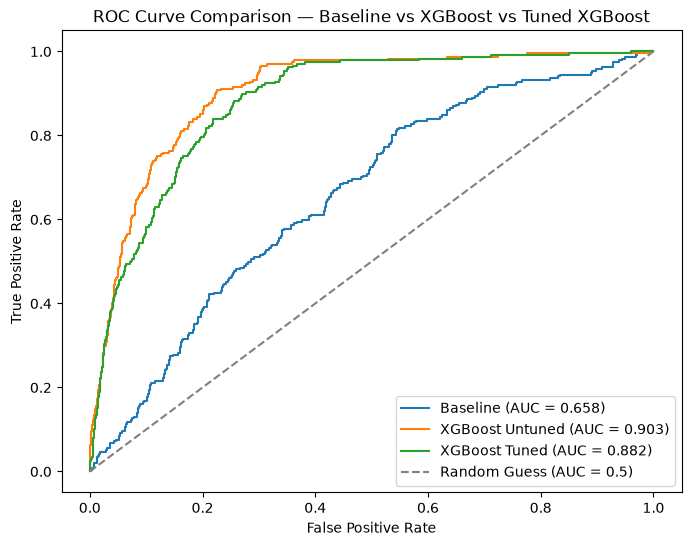

In [7]:
# Calculate the ROC curve points (False Positive Rate, True Positive Rate) for each model
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_proba_baseline)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)

plt.figure(figsize=(8, 6))

plt.plot(fpr_baseline, tpr_baseline, label=f"Baseline (AUC = {roc_auc_score(y_test, y_proba_baseline):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost Untuned (AUC = {roc_auc_score(y_test, y_proba_xgb):.3f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"XGBoost Tuned (AUC = {roc_auc_score(y_test, y_proba_tuned):.3f})")

# The diagonal line = what a "random guess" model would look like
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Baseline vs XGBoost vs Tuned XGBoost")
plt.legend()
plt.savefig("../Results/roc_curve_day12.png", dpi=150, bbox_inches="tight")
plt.show()